# DreamerV3 Training Analysis

This notebook parses and visualizes training metrics from DreamerV3 experiments.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Configuration

Set the path to the experiment results folder containing `metrics.jsonl` and `scores.jsonl`.

In [2]:
# Path to the experiment results folder
RESULTS_PATH = Path("/scratch/frutiger/isaacp/dreamerv3_logs/anymal_c_soccer")

# Verify the path exists
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"Results path not found: {RESULTS_PATH.resolve()}")

print(f"Loading results from: {RESULTS_PATH.resolve()}")

Loading results from: /scratch/frutiger/isaacp/dreamerv3_logs/anymal_c_soccer


## Load Data

Parse the JSONL files into pandas DataFrames.

In [3]:
def load_jsonl(filepath: Path) -> pd.DataFrame:
    """Load a JSONL file into a pandas DataFrame."""
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

# Load metrics and scores
metrics_path = RESULTS_PATH / "metrics.jsonl"
scores_path = RESULTS_PATH / "scores.jsonl"

metrics_df = load_jsonl(metrics_path) if metrics_path.exists() else pd.DataFrame()
scores_df = load_jsonl(scores_path) if scores_path.exists() else pd.DataFrame()

print(f"Metrics: {len(metrics_df)} records")
print(f"Scores: {len(scores_df)} records")

# Display sample data
if not metrics_df.empty:
    print("\nMetrics columns:", metrics_df.columns.tolist())
    display(metrics_df.head())

Metrics: 21872 records
Scores: 19750 records

Metrics columns: ['step', 'episode/score', 'episode/length', 'train/adv', 'train/adv_mag', 'train/adv_std', 'train/con', 'train/dyn_ent', 'train/ent/action', 'train/loss/con', 'train/loss/dyn', 'train/loss/image', 'train/loss/policy', 'train/loss/rep', 'train/loss/repval', 'train/loss/rew', 'train/loss/value', 'train/opt/grad_norm', 'train/opt/grad_rms', 'train/opt/loss', 'train/opt/param_count', 'train/opt/param_rms', 'train/opt/update_rms', 'train/opt/updates', 'train/rep_ent', 'train/ret', 'train/ret_max', 'train/ret_min', 'train/ret_rate', 'train/rew', 'train/slowval', 'train/tar', 'train/val', 'train/weight', 'epstats/reward_rate', 'replay/items', 'replay/chunks', 'replay/streams', 'replay/ram_gb', 'replay/inserts', 'replay/samples', 'replay/updates', 'replay/replay_ratio', 'usage/psutil/proc_cpu_usage', 'usage/psutil/proc_ram_frac', 'usage/psutil/proc_ram_gb', 'usage/psutil/total_cpu_count', 'usage/psutil/total_cpu_frac', 'usage/psuti

,step,episode/score,episode/length,train/adv,train/adv_mag,train/adv_std,train/con,train/dyn_ent,train/ent/action,train/loss/con,...,usage/psutil/total_ram_used_gb,usage/psutil/total_ram_avail_gb,usage/nvsmi/compute_min/gpu0,usage/nvsmi/compute_avg/gpu0,usage/nvsmi/compute_max/gpu0,usage/nvsmi/memory_min/gpu0,usage/nvsmi/memory_avg/gpu0,usage/nvsmi/memory_max/gpu0,fps/policy,fps/train
0,832,-1.209364,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1376,-2.183003,69.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2564,-3.353267,129.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10848,-16.379809,543.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15440,-23.856997,772.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Episode Score Over Training

Plot the episode scores over training steps with a smoothed trend line.

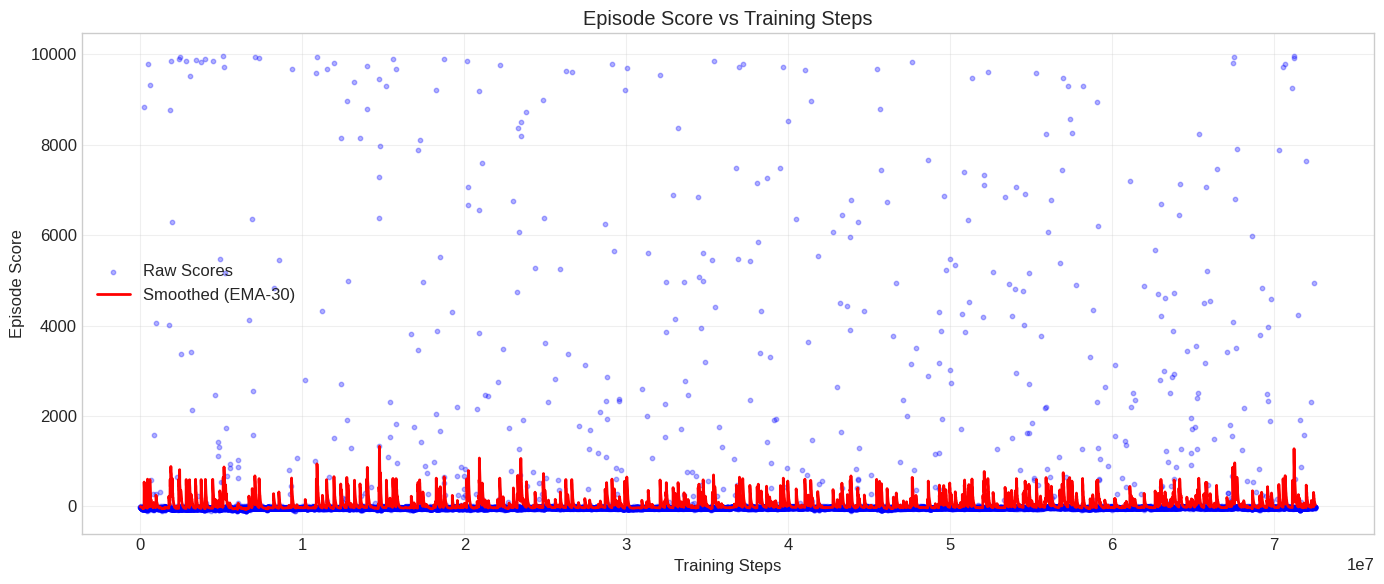

In [4]:
def smooth(data, window=20):
    """Apply exponential moving average smoothing."""
    return pd.Series(data).ewm(span=window, adjust=False).mean()

if not scores_df.empty and 'step' in scores_df.columns and 'episode/score' in scores_df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Sort by step
    df = scores_df.sort_values('step')
    
    # Plot raw scores
    ax.scatter(df['step'], df['episode/score'], alpha=0.3, s=10, label='Raw Scores', color='blue')
    
    # Plot smoothed trend
    smoothed = smooth(df['episode/score'], window=30)
    ax.plot(df['step'], smoothed, color='red', linewidth=2, label='Smoothed (EMA-30)')
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Episode Score')
    ax.set_title('Episode Score vs Training Steps')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Score data not available or missing required columns")

## Episode Length Over Training

Track how episode lengths change during training.

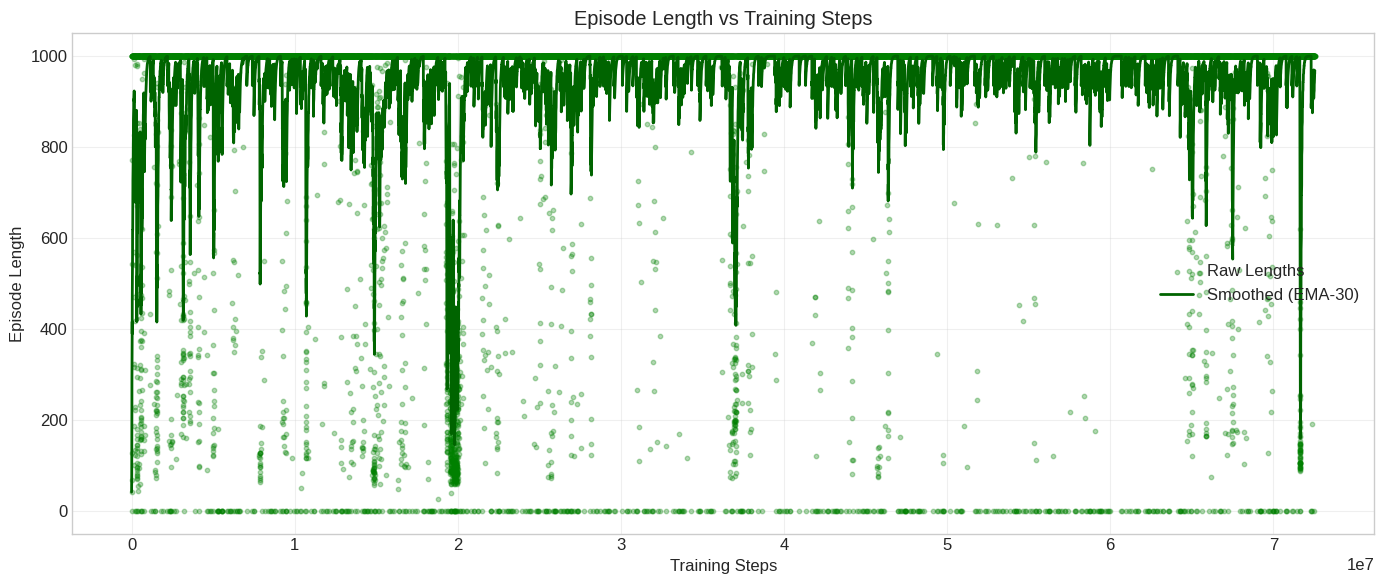

In [5]:
if not metrics_df.empty and 'step' in metrics_df.columns and 'episode/length' in metrics_df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Sort by step
    df = metrics_df.sort_values('step')
    
    # Plot raw lengths
    ax.scatter(df['step'], df['episode/length'], alpha=0.3, s=10, label='Raw Lengths', color='green')
    
    # Plot smoothed trend
    smoothed = smooth(df['episode/length'], window=30)
    ax.plot(df['step'], smoothed, color='darkgreen', linewidth=2, label='Smoothed (EMA-30)')
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Episode Length')
    ax.set_title('Episode Length vs Training Steps')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Episode length data not available")

## Combined Metrics View

Display score and episode length side-by-side.

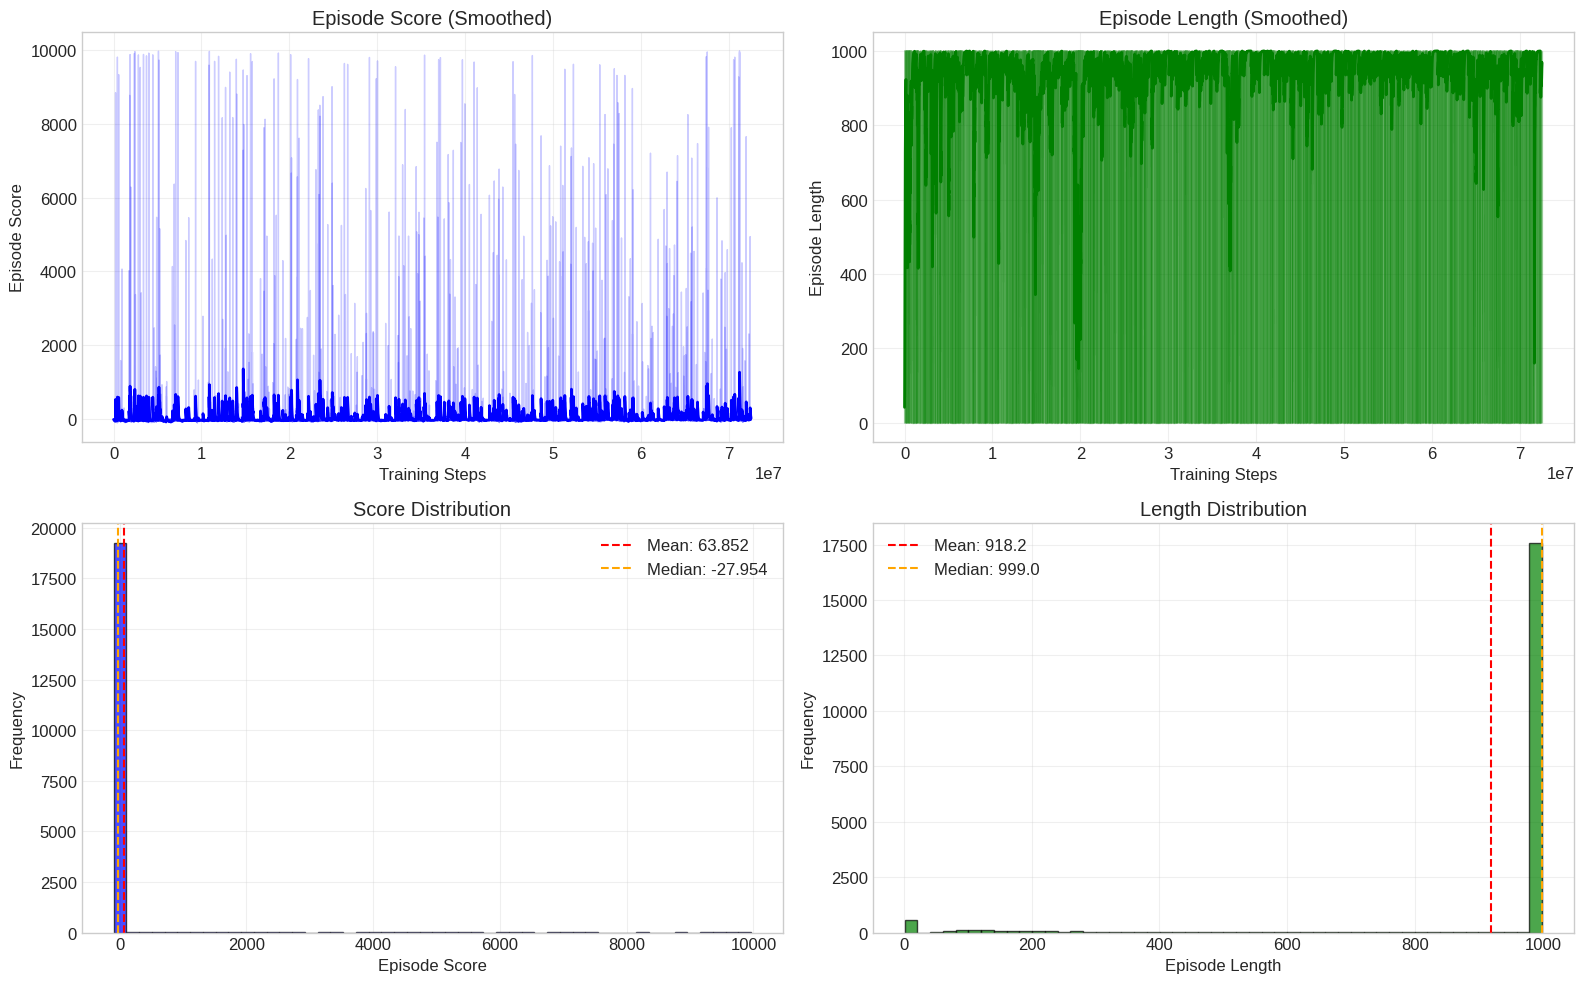

In [6]:
if not metrics_df.empty and 'episode/score' in metrics_df.columns and 'episode/length' in metrics_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    df = metrics_df.sort_values('step')
    
    # Score over time (smoothed)
    ax1 = axes[0, 0]
    smoothed_score = smooth(df['episode/score'], window=30)
    ax1.plot(df['step'], smoothed_score, color='blue', linewidth=2)
    ax1.fill_between(df['step'], df['episode/score'], alpha=0.2, color='blue')
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Episode Score')
    ax1.set_title('Episode Score (Smoothed)')
    ax1.grid(True, alpha=0.3)
    
    # Length over time (smoothed)
    ax2 = axes[0, 1]
    smoothed_length = smooth(df['episode/length'], window=30)
    ax2.plot(df['step'], smoothed_length, color='green', linewidth=2)
    ax2.fill_between(df['step'], df['episode/length'], alpha=0.2, color='green')
    ax2.set_xlabel('Training Steps')
    ax2.set_ylabel('Episode Length')
    ax2.set_title('Episode Length (Smoothed)')
    ax2.grid(True, alpha=0.3)
    
    # Score distribution
    ax3 = axes[1, 0]
    ax3.hist(df['episode/score'], bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax3.axvline(df['episode/score'].mean(), color='red', linestyle='--', label=f"Mean: {df['episode/score'].mean():.3f}")
    ax3.axvline(df['episode/score'].median(), color='orange', linestyle='--', label=f"Median: {df['episode/score'].median():.3f}")
    ax3.set_xlabel('Episode Score')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Score Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Length distribution
    ax4 = axes[1, 1]
    ax4.hist(df['episode/length'], bins=50, color='green', alpha=0.7, edgecolor='black')
    ax4.axvline(df['episode/length'].mean(), color='red', linestyle='--', label=f"Mean: {df['episode/length'].mean():.1f}")
    ax4.axvline(df['episode/length'].median(), color='orange', linestyle='--', label=f"Median: {df['episode/length'].median():.1f}")
    ax4.set_xlabel('Episode Length')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Length Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Metrics data not available for combined view")

## Summary Statistics

Key statistics from the training run.

In [7]:
if not metrics_df.empty:
    print("=== Training Summary ===\n")
    
    if 'step' in metrics_df.columns:
        print(f"Total Training Steps: {metrics_df['step'].max():,}")
        print(f"Number of Episodes:   {len(metrics_df)}")
    
    if 'episode/score' in metrics_df.columns:
        scores = metrics_df['episode/score']
        print(f"\nScore Statistics:")
        print(f"  Mean:   {scores.mean():.4f}")
        print(f"  Std:    {scores.std():.4f}")
        print(f"  Min:    {scores.min():.4f}")
        print(f"  Max:    {scores.max():.4f}")
        print(f"  Median: {scores.median():.4f}")
        
        # Best scores (last 10% of training)
        last_10pct = metrics_df.tail(len(metrics_df) // 10)
        if len(last_10pct) > 0:
            print(f"\nLast 10% Mean Score: {last_10pct['episode/score'].mean():.4f}")
    
    if 'episode/length' in metrics_df.columns:
        lengths = metrics_df['episode/length']
        print(f"\nLength Statistics:")
        print(f"  Mean:   {lengths.mean():.1f}")
        print(f"  Std:    {lengths.std():.1f}")
        print(f"  Min:    {lengths.min():.1f}")
        print(f"  Max:    {lengths.max():.1f}")
else:
    print("No metrics data available")

=== Training Summary ===

Total Training Steps: 72,549,800
Number of Episodes:   21872

Score Statistics:
  Mean:   63.8521
  Std:    773.5681
  Min:    -96.3618
  Max:    9962.9213
  Median: -27.9542

Last 10% Mean Score: 84.7574

Length Statistics:
  Mean:   918.2
  Std:    246.2
  Min:    1.0
  Max:    999.0


## Rolling Window Analysis

Analyze score trends using rolling windows to track improvement.

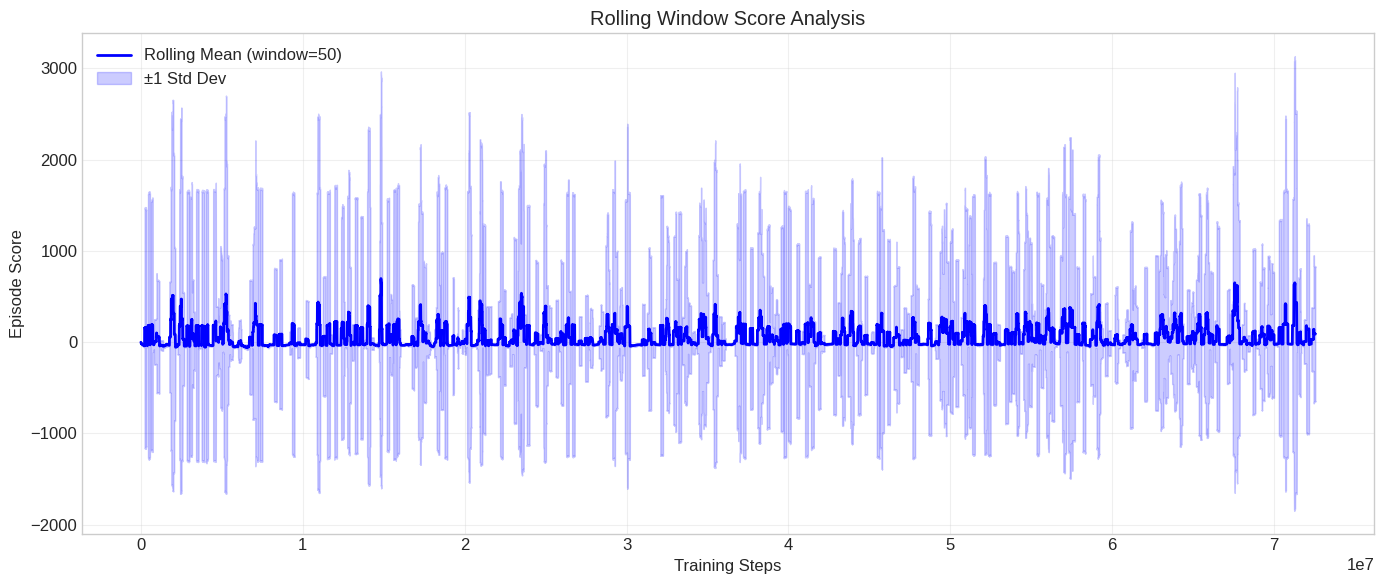

In [8]:
if not metrics_df.empty and 'episode/score' in metrics_df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df = metrics_df.sort_values('step')
    
    # Calculate rolling statistics
    window_size = min(50, len(df) // 10) if len(df) > 10 else len(df)
    rolling_mean = df['episode/score'].rolling(window=window_size, min_periods=1).mean()
    rolling_std = df['episode/score'].rolling(window=window_size, min_periods=1).std()
    
    # Plot
    ax.plot(df['step'], rolling_mean, color='blue', linewidth=2, label=f'Rolling Mean (window={window_size})')
    ax.fill_between(df['step'], 
                    rolling_mean - rolling_std, 
                    rolling_mean + rolling_std, 
                    alpha=0.2, color='blue', label='±1 Std Dev')
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Episode Score')
    ax.set_title('Rolling Window Score Analysis')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Score data not available for rolling analysis")